In [ ]:
'''
Russell Larkin
UMGC DATA430 Assignment 3
Professor Yamil Guevara
'''

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Load the dataset and display its information
my_data = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv", delimiter=",")
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [3]:
# Drop demographic columns to focus on features related to obesity
minus_demographic_df = my_data.drop(columns=['Height', 'Weight', 'Gender', 'Age'])

In [4]:
minus_demographic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   family_history_with_overweight  2111 non-null   object 
 1   FAVC                            2111 non-null   object 
 2   FCVC                            2111 non-null   float64
 3   NCP                             2111 non-null   float64
 4   CAEC                            2111 non-null   object 
 5   SMOKE                           2111 non-null   object 
 6   CH2O                            2111 non-null   float64
 7   SCC                             2111 non-null   object 
 8   FAF                             2111 non-null   float64
 9   TUE                             2111 non-null   float64
 10  CALC                            2111 non-null   object 
 11  MTRANS                          2111 non-null   object 
 12  NObeyesdad                      21

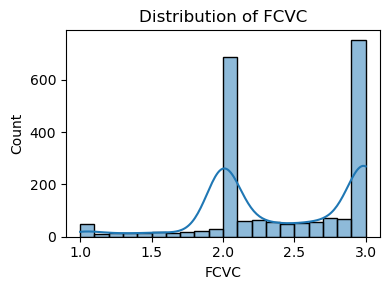

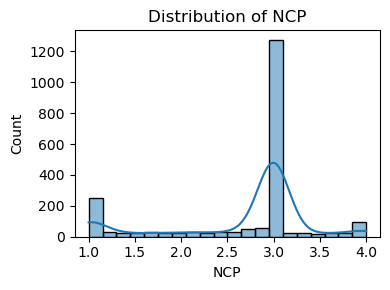

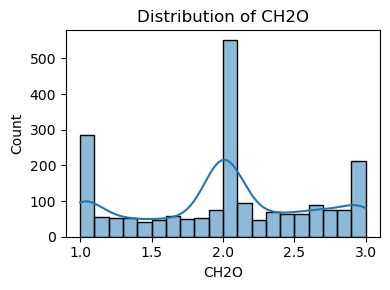

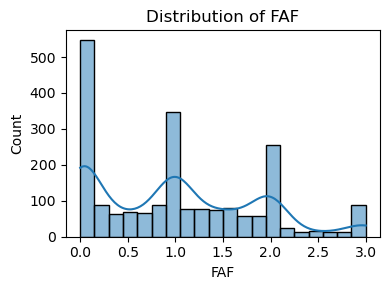

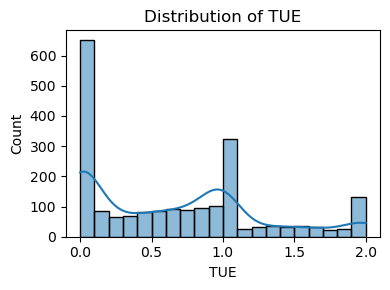

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_features = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_features = ['family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

for feature in numeric_features:
    plt.figure(figsize=(4, 3))
    sns.histplot(my_data[feature], bins=20, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

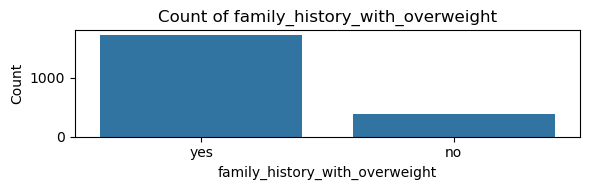

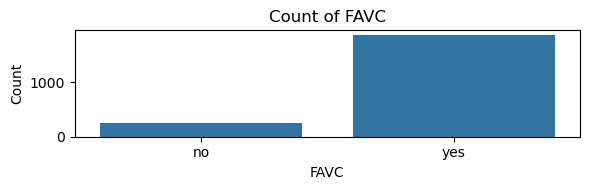

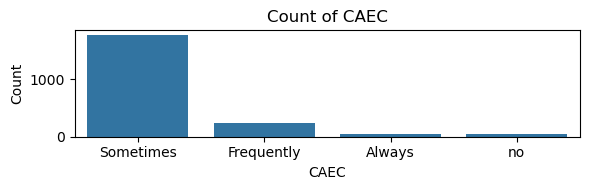

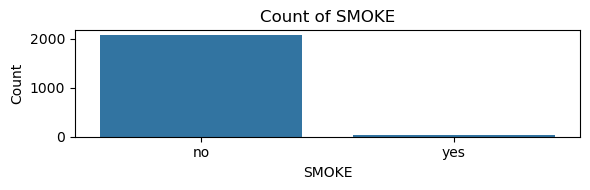

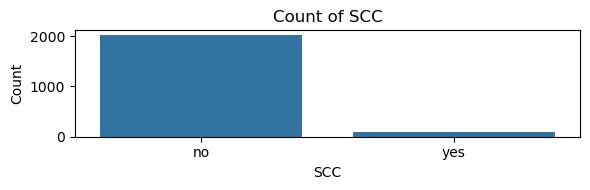

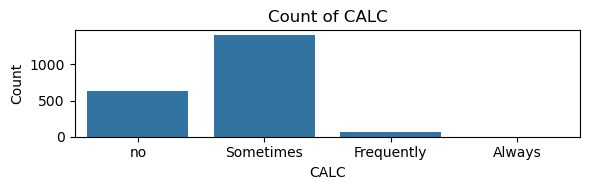

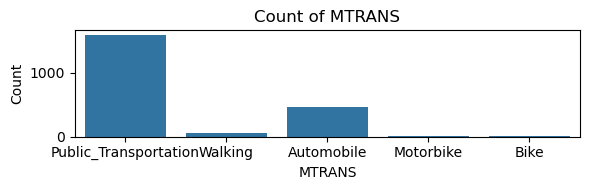

In [6]:
for feature in categorical_features:
    plt.figure(figsize=(6, 2))
    sns.countplot(x=feature, data=my_data)
    plt.title(f'Count of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

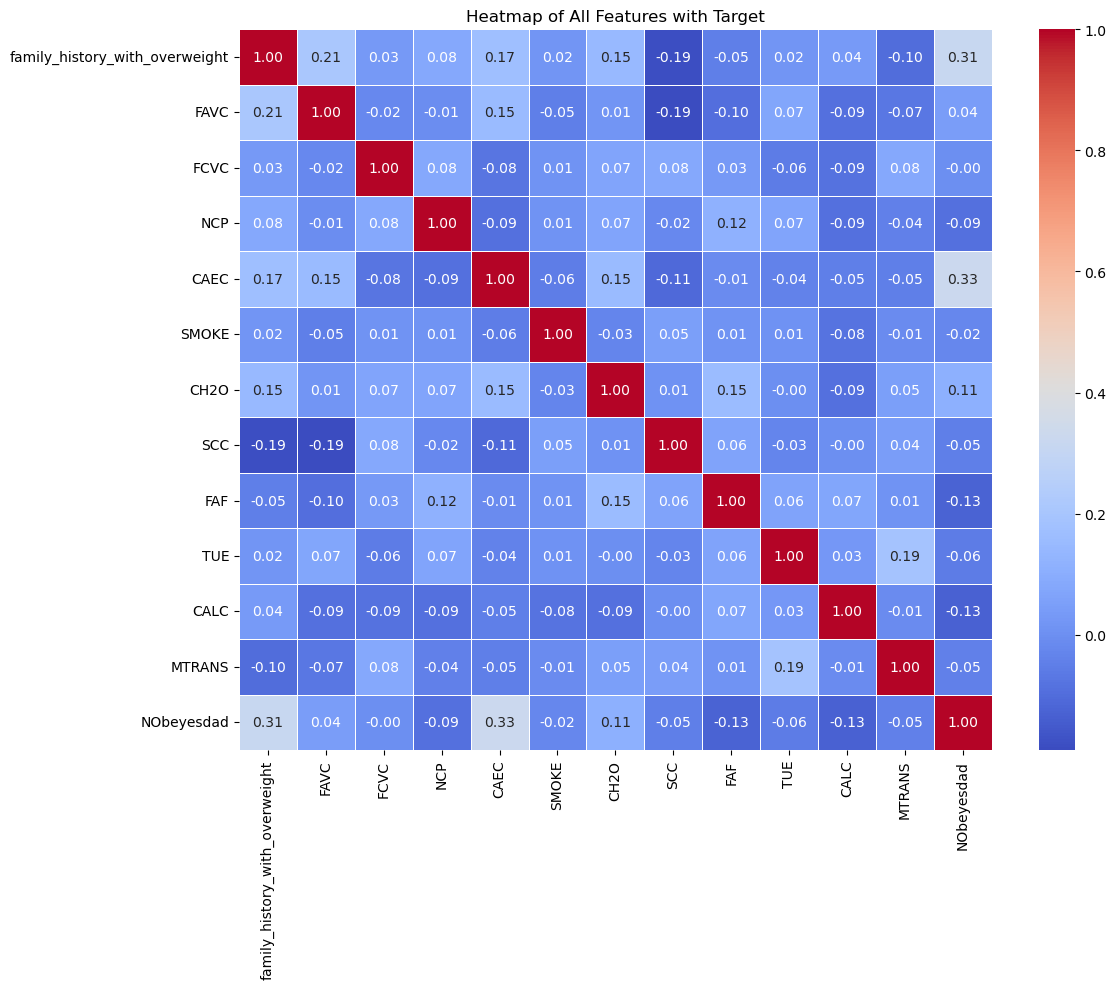

In [7]:
from sklearn import preprocessing

# Create a correlation heatmap of all features to visualize relationships
corr_heatmap = minus_demographic_df.copy()

for col in corr_heatmap:
    le = preprocessing.LabelEncoder()
    corr_heatmap[col] = le.fit_transform(corr_heatmap[col])
    
corr_matrix = corr_heatmap.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of All Features with Target")
plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder

# Drop demographic columns and prepare features
X = my_data.drop(columns=['Gender', 'Age', 'Height', 'Weight', 'NObeyesdad'])

# Encode features with LabelEncoder
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col]).astype(int)

X

,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,1,0,2.0,3.0,2,0,2.000000,0,0.000000,1.000000,3,3
1,1,0,3.0,3.0,2,1,3.000000,1,3.000000,0.000000,2,3
2,1,0,2.0,3.0,2,0,2.000000,0,2.000000,1.000000,1,3
3,0,0,3.0,3.0,2,0,2.000000,0,2.000000,0.000000,1,4
4,0,0,2.0,1.0,2,0,2.000000,0,0.000000,0.000000,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...
2106,1,1,3.0,3.0,2,0,1.728139,0,1.676269,0.906247,2,3
2107,1,1,3.0,3.0,2,0,2.005130,0,1.341390,0.599270,2,3
2108,1,1,3.0,3.0,2,0,2.054193,0,1.414209,0.646288,2,3
2109,1,1,3.0,3.0,2,0,2.852339,0,1.139107,0.586035,2,3


In [9]:
# Round all values in X to 2 decimal places
X = X.round(2)

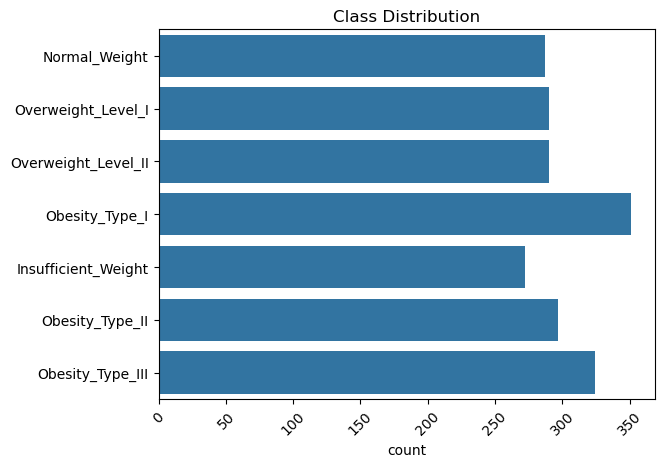

In [10]:
# Set Target to y
y = my_data["NObeyesdad"].values

# Show distribution
sns.countplot(y)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=3)
X['healthy_cluster'] = kmeans.fit_predict(X[['CH2O', 'FAF', 'FCVC', 'NCP']])
X['indulgence_cluster'] = kmeans.fit_predict(X[['CAEC', 'CALC', 'MTRANS', 'SMOKE']])


In [12]:
# Display the shapes and unique values of X and y

print("X shape:", X.shape)
print("Unique features in X:", X.columns.tolist())
print("y shape:", y.shape)
print("Unique labels in y:", np.unique(y))

X shape: (2111, 14)
Unique features in X: ['family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'healthy_cluster', 'indulgence_cluster']
y shape: (2111,)
Unique labels in y: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [13]:
# Encode the target variable y to work with XGBoost

le_y = LabelEncoder()
y = le_y.fit_transform(y)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# from sklearn.ensemble import RandomForestClassifier - rejected due to performance issues
# from sklearn.tree import DecisionTreeClassifier - rejected due to performance issues
from xgboost import XGBClassifier

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4)

# Train with XGBClassifier
overweightTree = XGBClassifier(
    n_estimators=100, 
    max_depth=3, 
    random_state=3, 
    learning_rate=0.1,
    subsample=0.8,
)
overweightTree.fit(X_train, y_train)
y_pred = overweightTree.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Training Accuracy:", accuracy_score(y_train, overweightTree.predict(X_train)))


Test Accuracy: 0.750788643533123
Training Accuracy: 0.8354773188896412


<Figure size 1000x600 with 0 Axes>

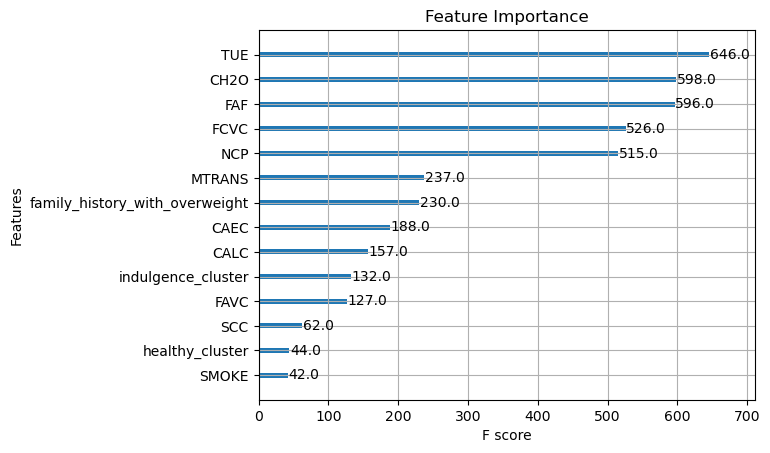

In [16]:
# Visualize feature importance using XGBoost's built-in function in lieu of visualizing the tree.

from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plot_importance(overweightTree)
plt.title("Feature Importance")
plt.show()


In [17]:
from sklearn.metrics import classification_report, confusion_matrix

# Print confusion matrix and classification report
print(confusion_matrix(y_test, y_pred))

[[68  8  2  0  1  3  3]
 [10 74  4  0  0  2  2]
 [ 1  7 61 11  1  0  7]
 [ 1  3  3 83  2  3  3]
 [ 0  0  0  0 97  0  0]
 [ 2  9 12  8  1 44  5]
 [ 0 13 17 10  1  3 49]]


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.80      0.81        85
           1       0.65      0.80      0.72        92
           2       0.62      0.69      0.65        88
           3       0.74      0.85      0.79        98
           4       0.94      1.00      0.97        97
           5       0.80      0.54      0.65        81
           6       0.71      0.53      0.60        93

    accuracy                           0.75       634
   macro avg       0.76      0.74      0.74       634
weighted avg       0.76      0.75      0.75       634



In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

# 5-fold cross-validation using existing X and y
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = XGBClassifier(n_estimators=100, max_depth=3, subsample=0.8, learning_rate=0.1,
                    eval_metric='mlogloss')

cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))

Cross-Validation Accuracy Scores: [0.76359338 0.7014218  0.72274882 0.71327014 0.73933649]
Mean Accuracy: 0.7280741263598983


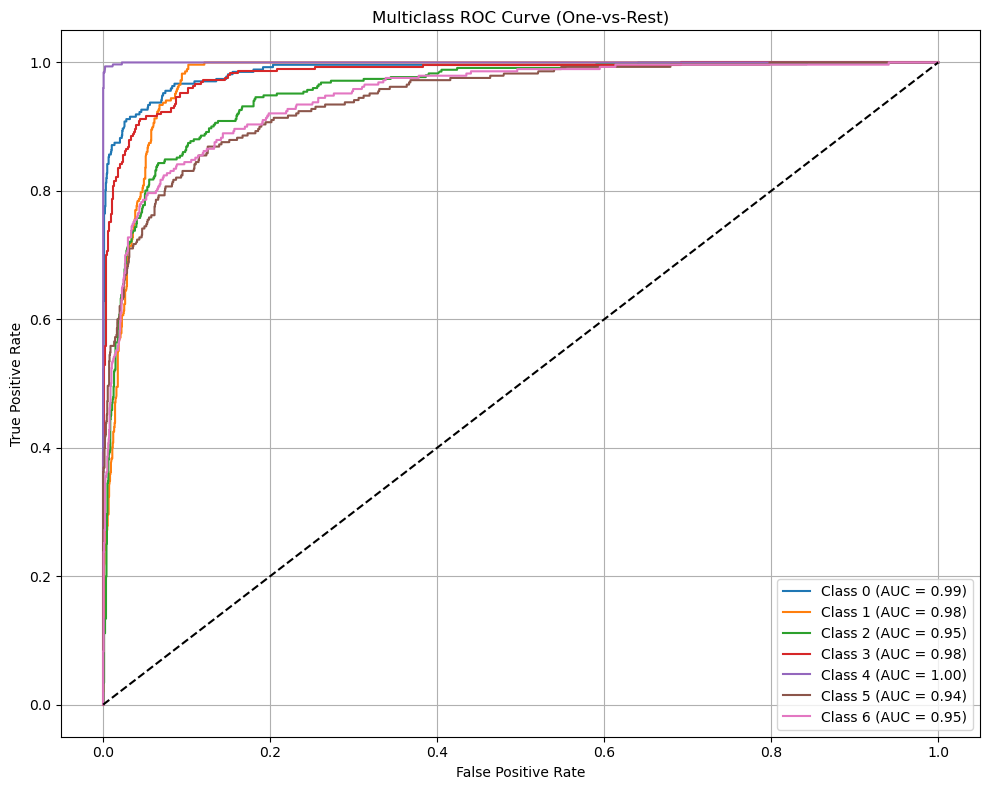

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize y for ROC curve plotting only (do not modify original y)
y_bin = label_binarize(y, classes=np.unique(y))
n_classes = y_bin.shape[1]

# Fit one-vs-rest model
ovr_model = OneVsRestClassifier(clf)
ovr_model.fit(X, y_bin)
y_score = ovr_model.predict_proba(X)

# Compute ROC curve and AUC
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()